In [83]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

In [84]:
N = 6
N_dis = 2
wd = 0.6365091993031289
wm = 1.0
args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}
tlist = np.linspace(0, 100, 300)

dz = 0.2
dy = 0.2
dx = 0.2

reals = 100

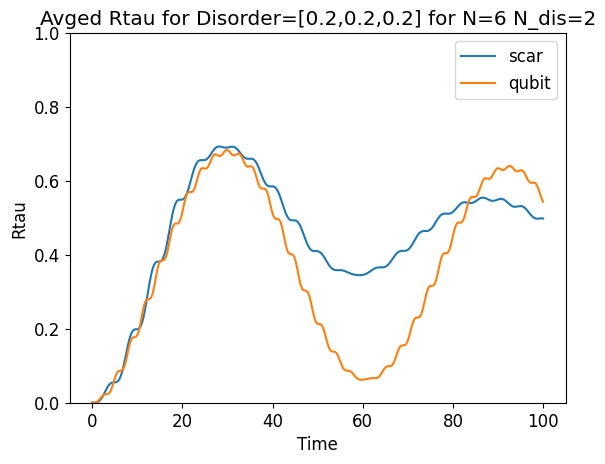

In [85]:
total_Rtau = np.zeros(len(tlist))
for _ in range(reals):
    H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, ham_disorder=[dz, dy, dx], N_dis=N_dis, random_seed=True)
    band = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau = np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])
    total_Rtau += Rtau

total_Rtau = total_Rtau / reals


full_qubit = 0
for _ in range(reals):
    qH0, qH1 = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx], random_seed=True, N_dis=N_dis)
    qeigenvalues, qeigenstates = qH0.eigenstates()
    qbandwidth = qeigenvalues[-1] - qeigenvalues[0]

    qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
    Rtau_qubit = np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qbandwidth)
    full_qubit += Rtau_qubit

full_qubit = full_qubit / reals

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N} N_dis={N_dis}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, total_Rtau, label="scar")
plt.plot(tlist, full_qubit, label="qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()